In [1]:
using Printf
using Plots
using LinearAlgebra
using Symbolics
using Symbolics: substitute, derivative

This project is based on homework assignments from the course "PHYS 420: Computational Physics" taught by Dr. Sacchi, University of Alberta. All code and explanations here are my own implementation and interpretation.

### Four-mass, five-spring chain
The displacement of mass $i$ is denoted with a vector representing all displacements,
$$\mathbf{x}(t) \begin{bmatrix} x_1(t) \\ x_2(t) \\ x_3(t) \\ x_4(t) \end{bmatrix}$$
Each $x_i$ is measured with respect to the unstretched, or equilibrium, position. With four masses, there are five springs, connected the coupled system to a rigid wall on either side. The masses are labelled with $i \in [1, 4]$ with the walls being 0 and 5 appropriately. The springs are numbered as $i \in [0, 4]$.

Equation of motion: $m \ddot{x}_i(t) = -(k_{i-1} + k_i)x_i(t) + k_{i-1}x_{i-1}(t) + k_ix_{i+1}(t)$, $ \; \; \; \; x_0(t) = x_5(t) = 0$\

With stiffness matrix,
$$K = \begin{bmatrix} k_0+k_1 & -k_1 & 0 & 0  \\  -k_1 & k_1+k_2 & -k_2 & 0 \\  0 & -k_2 & k_2+k_3 & -k_3  \\  0 & 0 & -k_3 & k_3+k_4  \end{bmatrix}$$

For all components: $m\ddot{\mathbf{x}}(t) + K\mathbf{x}(t) = \mathbf{0}$

With K being symmetric and positive definite (SPD) for $k_i >0$, we have spectral decomposition: $K=Q \Lambda Q^{\top}$. Matrix $\Lambda$ is diagonal and matrix $Q$ is orthonormal, composed of the eigenvectors of the spectral decomposition of matrix $K$. Introduce modal coordinates,
$$\mathbf{y}(t) = Q^{\top}\mathbf{x}(t)$$

We can get scalar ODEs by left-multiplying by $Q^{\top}$ : $\ddot{y}_i(t) + \omega_i^2y_i(t)=0, \; \; \; \; i = 1, ..., 4$

Solutions: $y_i(t) = a_icos(\omega_it) + b_isin(\omega_it), \; \; \; \; \omega_i = \sqrt{\lambda_i/m}$


Setting initial conditions with $\mathbf{x}(0) \mathbf(x)_0$ and $\dot{\mathbf{x}}(0) = \mathbf{v}_0$, with $\Omega = \mathrm{diag}(\omega_1, \omega_2, \omega_3, \omega_4)$

$$\mathbf{x}_0 = Q\mathbf{a} \Longrightarrow \mathbf{a} = Q^{\top}\mathbf{x}_0$$
$$\mathbf{v}_0 = Q\Omega\mathbf{b} \Longrightarrow \mathbf{b} = \Omega^{-1}Q^{\top}\mathbf{v}_0$$

In [2]:
# @variables definies symbolic variables, I found it useful later on for differentiation
@variables k_0 k_1 k_2 k_3 k_4
@variables x_1 x_2 x_3 x_4

# Create matrix K
K = [k_0+k_1 -k_1 0 0;
     -k_1 k_1+k_2 -k_2 0;
     0 -k_2 k_2+k_3 -k_3;
     0 0 -k_3 k_3+k_4]

vec_x = [x_1 x_2 x_3 x_4]

if all(isequal.(K, K')) == true
    println(vec_x*K*vec_x')
else
    println("Not SPD")
end

Num[((k_0 + k_1)*x_1 - k_1*x_2)*x_1 + (-k_1*x_1 + (k_1 + k_2)*x_2 - k_2*x_3)*x_2 + (-k_2*x_2 + (k_2 + k_3)*x_3 - k_3*x_4)*x_3 + (-k_3*x_3 + (k_3 + k_4)*x_4)*x_4;;]


*println(all(isequal.(K, K')))*

We can compare the matrix $K$ and its transpose $K^T$ to see if all the elements match, if it's symmetric. We can check by using isequal.() to check element-wise if they are equal in both matrices, and all() will check if every element satisfies the condition. This returns boolean True, so matrix $K$ is symmetric.  

*vec_x K vec_x'* = $\textbf{x} K \textbf{x}^T$

The above line of code calculated the final expression after all the matrix/vector multiplication. By hand, it can be simplified to
$$k_0 x_1^2 + k_1(x_1 - x_2)^2 + k_2(x_2 - x_3)^2 + k_3(x_3 - x_4)^2 + k_4 x_4^2$$
where $k_i \gt 0$, and $\textbf{x}$ can be any value. Since all terms with $x_i$ are squared, this equation is always positive. Therefore, matrix $K$ is symmetric positive-definite, SPD.

In [3]:
# Finding eigenvalues/eigenvectors
K_num = substitute(K, Dict(k_0 => 100, k_1 => 120, k_2 => 140, k_3 => 10, k_4 => 30))
K_new = Float64.(Symbolics.value.(K_num))
mass = 0.5

result1 = eigen(K_new)
N = length(result1.values)

println("Eigenvectors (vertically):")
display(result1.vectors)   # columns are q_i, i = 1, ..., n

println("")

@printf("%-14s  %-12s  %-12s\n", "Eigenvalues", "ω [rad/s]", "f [Hz]")
@printf("%s\n", "-"^38)
for i in 1:N
    @printf("%-5f  %12.5f  %12.5f\n", result1.values[i], sqrt(result1.values[i]/mass), sqrt(result1.values[i]/mass)/(2*π))
end

Eigenvectors (vertically):


4×4 Matrix{Float64}:
 0.339717  -0.173745   0.787082   -0.484672
 0.555866  -0.256681   0.177815    0.770396
 0.64724   -0.249446  -0.589405   -0.414076
 0.395834   0.917444   0.0385509   0.0111688


Eigenvalues     ω [rad/s]     f [Hz]      
--------------------------------------
23.648714       6.87731       1.09456
42.718926       9.24326       1.47111
192.890016      19.64128       3.12601
410.742344      28.66155       4.56163


In [4]:
# Initializing matrix Q of the eigenvectors
Q = Array{Float64}(undef, 0, N)
for i in 1:N
    row = []
    for j in 0:N-1
        push!(row, result1.vectors[i+4*j])   # add values going down the rows (so along the columns) to get the eigenvector
    end
    Q = vcat(Q, row')   # The eigenvectors aren't the rows, but the columns in Q
end

# Calculating the natural frequencies
ω = sqrt.(result1.values ./ mass)
C(t) = Matrix(Diagonal(cos.(ω .* t)))
S(t) = Matrix(Diagonal(sin.(ω .* t)))

dC(t) = Matrix(Diagonal(-ω .* sin.(ω .* t)))
dS(t) = Matrix(Diagonal(ω .* cos.(ω .* t)))

# Finding Ω by evaluating the derivative of S wrt t at t = 0
Ω = dS(0)

# Setting initial conditions
IC_x0 = [0.01, 0.0, 0.0, 0.0]
IC_v0 = [0.1, 0.2, 0.3, 0.4]

# Defining vectors a and b
a = Q'*IC_x0
b = inv(Ω)*Q'*IC_v0

# Equation to find x(t)
new_x(τ) = Q * C(τ) * a + Q * S(τ) * b

new_x (generic function with 1 method)

We got the eigenvectors from the previous section and they would be the columns in matrix $Q$. Then calculate the natural frequencies, $\omega _i$, from the eigenvalues, $\lambda _i$, to sub into the cos and sin matrices $(C, S)$ that are time-dependent. $\Omega$ is the diagonal matrix with the natural frequencies, and vectors $\textbf{a}$ and $\textbf{b}$ can be found from  
$$\textbf{a} = Q^T \textbf{x}_0,  \textbf{b} = \Omega^{-1} Q^T \textbf{v}_0$$
where $\textbf{x}_0$ and $\textbf{v}_0$ are the initial conditions for the positions and velocities of the respective mass. We can then get the position vector from
$$\textbf{x}(t) = Q C(t) \textbf{a} + Q S(t) \textbf{b}$$

Below is the plot of the position of each mass, $x_i$, as a function of the time.

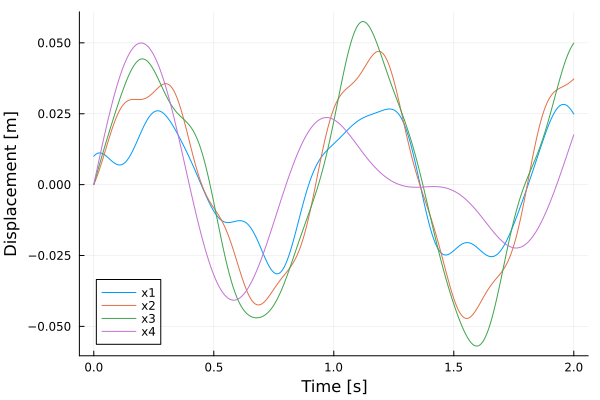

In [5]:
τ = 0:0.001:2
all_x = reduce(hcat, new_x.(τ))   # evaluates for vector x for all time values, element-wise
plot(τ, eachrow(all_x), label = ["x1" "x2" "x3" "x4"], xlabel = "Time [s]", ylabel = "Displacement [m]")

The inverse problem is solvable as long as we have the natural frequencies, $ω$, and the eigenvectors (for matrix $Q$), we can also find the eigenvalues using equation $ω_i = \sqrt{λ_i/m}$. This will give us matrix $\Lambda$, and matrix $K$ can be found from $K = Q\Lambda Q^T$. With boundary conditions, the system of equations can be solved for to find any $k_i$.  

In terms of the code, this would be straight forward to get $K$ numerically just by building $Q$ and $\Lambda$ with the given information. For solving the system of equations and finding the values $k_i$, we'd have the numerical value it should be from $Q\Lambda Q^T$, so we can solve element-wise for the spring constants.

### Eigenstates of a Smoothed "Infinite" Well
Revisiting the time-independent Schrödinger's equation for a particle in a one-dimensional potential well
$$-\frac{\hbar^2}{2m} \frac{d^2 \psi(x)}{dx^2} + V(x)\psi(x) = E \psi(x)$$,
when aiming to model it, a smoothed infinite well can be used in place of the perfect square well. A well with half-width $a$ and of potential:
$$V(x) = V_0[1-\frac{1}{2} (\mathrm{tanh}(\alpha(x+a)) - \mathrm{tanh}(\alpha(x-a)))]]$$
where $V_0>>1$ acts as the infinite barrier and the parameter $\alpha>0$ controls how sharp the walls are. With $\alpha \rightarrow \infty$, the potential acts closer to a true infinite square well.

The constants $\hbar$, $m$, and $a$ are all treated as non-dimensional and in natural units.

The Hamiltonian then becomes
$$H = -\frac{1}{2}L+\mathrm{diag}(V(x))$$

In [6]:
@variables α, V0
ħ = 1
mass = 1
a = 1
α = 100

# Creating a discretized domain
X = range(-2*a, 2*a, length=1000)
Δx = step(X)

function get_laplacian(dx, grid)
    dN = length(grid)
    diag = fill(-2, dN)
    off_diag = fill(1, dN-1)
    return SymTridiagonal(diag, off_diag)/dx^2
end
get_laplacian(Δx, X)

1000×1000 SymTridiagonal{Float64, Vector{Float64}}:
    -1.2475e5  62375.1            ⋅        …       ⋅             ⋅ 
 62375.1          -1.2475e5  62375.1               ⋅             ⋅ 
      ⋅        62375.1          -1.2475e5          ⋅             ⋅ 
      ⋅             ⋅        62375.1               ⋅             ⋅ 
      ⋅             ⋅             ⋅                ⋅             ⋅ 
      ⋅             ⋅             ⋅        …       ⋅             ⋅ 
      ⋅             ⋅             ⋅                ⋅             ⋅ 
      ⋅             ⋅             ⋅                ⋅             ⋅ 
      ⋅             ⋅             ⋅                ⋅             ⋅ 
      ⋅             ⋅             ⋅                ⋅             ⋅ 
      ⋅             ⋅             ⋅        …       ⋅             ⋅ 
      ⋅             ⋅             ⋅                ⋅             ⋅ 
      ⋅             ⋅             ⋅                ⋅             ⋅ 
     ⋮                                     ⋱                
   

In [7]:
V0 = 100   # potential barrier of both wells

function potential(x; α, V0, a)
    V(x) = V0*(1 - 1/2*(tanh(α*(x + a)) - tanh(α*(x - a))))
    return V.(x)
end

function hamiltonian(dx, x, V_vector)
    L = get_laplacian(dx, x)
    H = -1/2*L + diagm(V_vector)
    return H
end
hamiltonian(Δx, X, potential(X; α, V0, a))

1000×1000 Matrix{Float64}:
  62475.1  -31187.5       0.0       0.0  …       0.0       0.0       0.0
 -31187.5   62475.1  -31187.5       0.0          0.0       0.0       0.0
      0.0  -31187.5   62475.1  -31187.5          0.0       0.0       0.0
      0.0       0.0  -31187.5   62475.1          0.0       0.0       0.0
      0.0       0.0       0.0  -31187.5          0.0       0.0       0.0
      0.0       0.0       0.0       0.0  …       0.0       0.0       0.0
      0.0       0.0       0.0       0.0          0.0       0.0       0.0
      0.0       0.0       0.0       0.0          0.0       0.0       0.0
      0.0       0.0       0.0       0.0          0.0       0.0       0.0
      0.0       0.0       0.0       0.0          0.0       0.0       0.0
      0.0       0.0       0.0       0.0  …       0.0       0.0       0.0
      0.0       0.0       0.0       0.0          0.0       0.0       0.0
      0.0       0.0       0.0       0.0          0.0       0.0       0.0
      ⋮                 

The function 'get_laplacian' will build the second-order finite-difference Laplacian operator for some discritized grid x with spacing dx. In this case, $X = [-2a, 2a]$ with step size $\Delta x = 1000$. The vectors for the diagonal and the off diagonal components are created using fill(), with the off diagonal being one element smaller. Using SymTridiagonal and dividing by $\Delta x^2$, the Laplacian, matrix $L$, can be made.

The Hamiltonian can then be constructed, given a potential $V_0$ that bounds the particle inside the well. The function will create it's own Laplacian operator based on the step size and grid given, and will create the matrix using
$$H = -\frac{1}{2}L + diag(V(x))$$
where $V(x)$ has the same shape as $L$.

In [8]:
function normalise_ψ(dx, Ψ)
    for i in 1:size(Ψ, 2)
        norm = sqrt(sum(abs2, Ψ[:, i]) * dx)   # abs2 takes absolute value squared, sum does Riemann sum
        Ψ[:, i] ./= norm   # normalizes it and replaces that position
    end
end

# Extracting the energy values and eigenfunctions, then normalizing them
results = eigen(hamiltonian(Δx, X, potential(X; α, V0, a)))
En = results.values
ψ = results.vectors
normalise_ψ(Δx, ψ)

In [9]:
En_eq(n) = (π*n)^2/(8*a^2)
n = 1:length(En)

En_exact = En_eq.(n)
abs_diff = abs.(En .- En_exact)

@printf("%-11s  %-10s  %-10s  %-12s\n", "n", "En", "En_exact", "|En-En_exact|")
@printf("%s\n", "-"^50)
for i in 1:10
    @printf("%-5d  %10.2f  %12.2f  %12.2f\n", n[i], En[i], En_exact[i], abs_diff[i])
end

n            En          En_exact    |En-En_exact|
--------------------------------------------------
1            1.08          1.23          0.16
2            4.31          4.93          0.63
3            9.68         11.10          1.42
4           17.18         19.74          2.56
5           26.77         30.84          4.08
6           38.40         44.41          6.01
7           51.99         60.45          8.46
8           67.39         78.96         11.57
9           84.22         99.93         15.71
10         100.52        123.37         22.85


Good agreement between the analytical $E_n^{exact}$ and the numerical $E_n$ holds for lower energy states, but the difference continues to grow as we go to larger n, thereby making it unreliable for higher energy states.

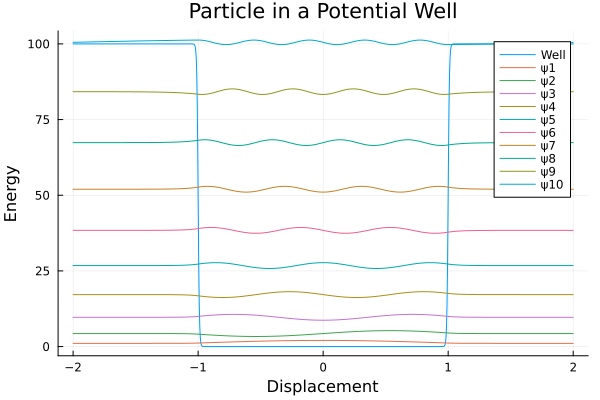

In [10]:
plot(X, [potential(X; α, V0, a), En[1].+ψ[:, 1], En[2].+ψ[:, 2], En[3].+ψ[:, 3], En[4].+ψ[:, 4], En[5].+ψ[:, 5], En[6].+ψ[:, 6], En[7].+ψ[:, 7], En[8].+ψ[:, 8], En[9].+ψ[:, 9], En[10].+ψ[:, 10]], labels = ["Well" "ψ1" "ψ2" "ψ3" "ψ4" "ψ5" "ψ6" "ψ7" "ψ8" "ψ9" "ψ10"], xlabel = "Displacement", ylabel = "Energy", title = "Particle in a Potential Well")

The plot above shows the eigenfunctions, $\psi _n$, for $n = [1, 10]$ in the well, shifted up by their respective energy level $E_n$. An $\alpha$ of 100 was used to approximate the well as a square well to reasonable accuracy. As the value of alpha decreases, the well become less and less like a square well and rather just becomes a smoothed well.  

In this case, an $n = 10$ has enough energy to sit above the well, and so would not be bound.

# Discussion

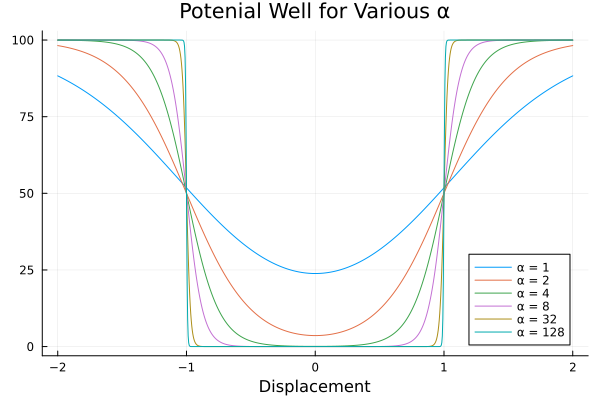

In [11]:
list = [1, 2, 4, 8, 32, 128]
p = plot(X, potential(X; α = list[1], V0, a), label = "α = $(list[1])", xlabel = "Displacement", title = "Potenial Well for Various α")
for b in list[2:end]
    plot!(p, X, potential(X; α = b, V0 = V0, a = a), label = "α = $b")    
end
display(p)

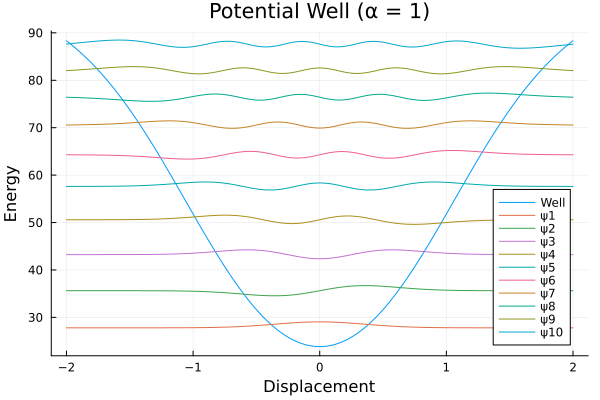

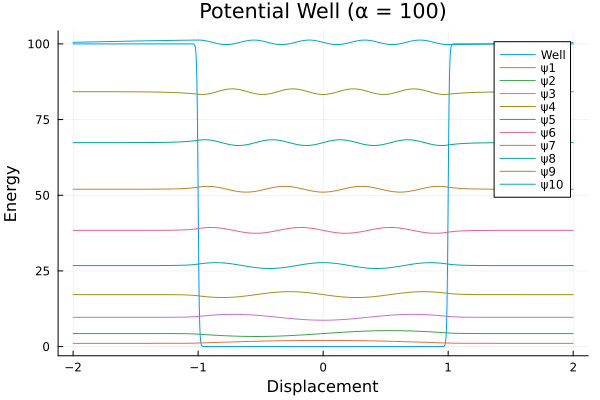

In [12]:
# list = [1, 2, 4, 8, 32, 128]
list = [1, 100]   # smoothing factors
for b in list
    Vα = potential(X; α = b, V0, a)
    results = eigen(hamiltonian(Δx, X, Vα))
    En = results.values
    ψ = results.vectors
    normalise_ψ(Δx, ψ)
    p = plot(X, [Vα, En[1].+ψ[:, 1], En[2].+ψ[:, 2], En[3].+ψ[:, 3], En[4].+ψ[:, 4], En[5].+ψ[:, 5], En[6].+ψ[:, 6], En[7].+ψ[:, 7], En[8].+ψ[:, 8], En[9].+ψ[:, 9], En[10].+ψ[:, 10]], labels = ["Well" "ψ1" "ψ2" "ψ3" "ψ4" "ψ5" "ψ6" "ψ7" "ψ8" "ψ9" "ψ10"], xlabel = "Displacement", ylabel = "Energy", title = "Potential Well (α = $b)")
    display(p)
end

The eigenfunctions, $\psi _n$, in the infinite square well all sit nicely in the boundaries $[-a, a]$ while in the smooth well, they stretch out past the well walls. In the infinite square well, the eigenfunctions fit nicely within the well and while it is mathematically neat, it isn't physical. In the smooth case, they seep outside the well into a classically forbidden region, this phenomenon being quantum tunneling.

The infinite square well has a $V = 0$ at the bottom, while the smooth well has a non-zero value as the lowest point. This is likely due to having a prescribed $V_0$, shifting it upwards.

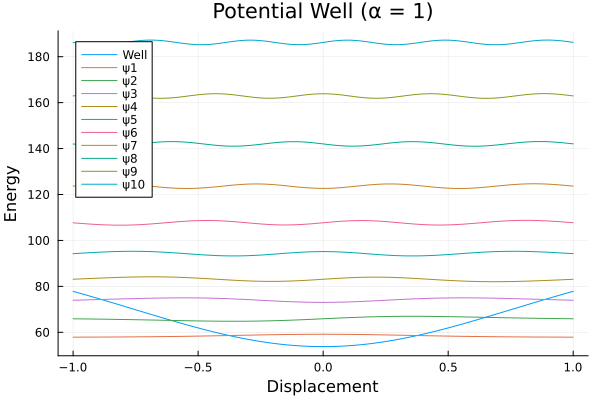

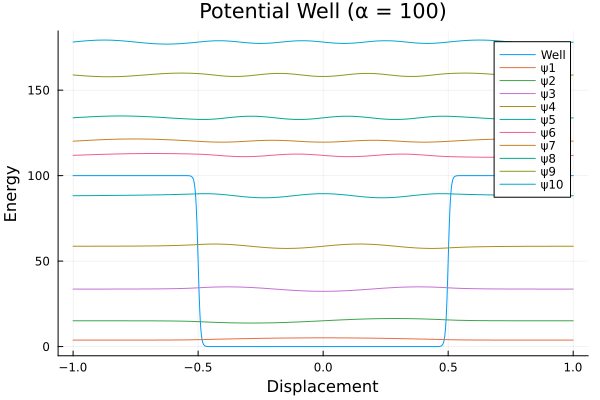

In [13]:
# The impact of the width on the well on the eigenvectors
list = [1, 100]
Y = range(-a, a, length=1000)
Δy = step(Y)
for b in list
    Vα = potential(Y; α = b, V0, a=0.5)
    results = eigen(hamiltonian(Δy, Y, Vα))
    En = results.values
    ψ = results.vectors
    normalise_ψ(Δy, ψ)
    p = plot(Y, [Vα, En[1].+ψ[:, 1], En[2].+ψ[:, 2], En[3].+ψ[:, 3], En[4].+ψ[:, 4], En[5].+ψ[:, 5], En[6].+ψ[:, 6], En[7].+ψ[:, 7], En[8].+ψ[:, 8], En[9].+ψ[:, 9], En[10].+ψ[:, 10]], labels = ["Well" "ψ1" "ψ2" "ψ3" "ψ4" "ψ5" "ψ6" "ψ7" "ψ8" "ψ9" "ψ10"], xlabel = "Displacement", ylabel = "Energy", title = "Potential Well (α = $b)")#, xlim = (-2, 2))
    display(p)
end

$$\psi _n = \sqrt{\frac{2}{L}}sin \left( \frac{n\pi x}{L}\right)$$
This formula show the dependence of the eigenvector $\psi _n$ on the full-width of the well, $L$. From this we can see that $\psi _n \propto \frac{1}{L^{1/2}}$ so as the width of the well decreases, the eigenvectors become more constricted, so there's more energy per $n$ as compared to before, which is also apparent from the equation for energy
$$E_n = \frac{\pi^2 n^2}{2L^2}$$